# **MoE Neural Network Prototype: 1 feature**
---

This Notebook implements a shallow  gating neural network following the architecture below:

```console

in_features -> Linear -> Tanh -> Linear -> number_of_weights
```
In the case of 1 feature and 3 experts:

```console

1 -> Linear -> Tanh -> Linear -> 3
```

Such architecture aims to provide understanding of the impact of a specific feature (or set of features) during the aggregation process.

For more details on the method please refer to the `README.md` file of this section.

In [1]:
# --- Main imports ---
import os
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

# --- Project path ---
PROJECT_PATH = os.path.dirname(os.getcwd())
PROJECT_PATH = os.getcwd()

MERGED_DATASET = f"{PROJECT_PATH}/data/experts_and_features_for_moe_nn.csv"


# --- Check files existence ---
files = [MERGED_DATASET]

for file in files:
    if os.path.exists(file):
        print(f"File O.k.! :\t{file}")
    else:
        print(f"File NOT O.k.! : {file}")

File O.k.! :	/home/mambo/Documents/Projet_fil_rouge/Neural_Network_Forecasting/data/experts_and_features_for_moe_nn.csv


In [2]:
# --- Load dataset ---
df_merged = pd.read_csv(MERGED_DATASET)

# --- Convert to datetime format ---
df_merged['Date_Heure'] = pd.to_datetime(df_merged['Date_Heure'], errors='coerce')

# --- Define how many months you want to retrieve ---
# Change this to 6 or 9 as needed
months_to_keep = 6

# --- Retrieve the cutoff date based on the months_to_keep and the latest date ---
latest_date = df_merged['Date_Heure'].max()
cutoff_date = latest_date - pd.DateOffset(months=months_to_keep)

# --- Retrieve data drom MERGED_DATAFRAME ---
df_recent = df_merged[df_merged['Date_Heure'] >= cutoff_date]

# --- Print span of the dataset ---
print(f"Start date: {df_recent['Date_Heure'].min()}")
print(f"Stop date: {df_recent['Date_Heure'].max()}")
print(f"Samples : {len(df_recent)}")

# --- Dataset overview ---
#df_recent.info()
df_recent.head()

Start date: 2025-05-23 23:00:00
Stop date: 2025-11-23 23:00:00
Samples : 4417


,Unnamed: 0,Date_Heure,y_true,ridge,randomforest,lgbm,Wind_Norm,Wind_Norm_Cubes,wind_cv_3h,Wind_Dir_Meteo_sin,Wind_Dir_Meteo_cos,Air_density,Hour_sin,Hour_cos,Month_sin,Month_cos
5591,5591,2025-05-23 23:00:00,1195.78,1069.538628,1154.031431,1133.145850,10.002179,1000.653964,0.030362,-0.687989,-0.725721,1.240147,-0.258819,0.965926,0.5,-0.866025
5592,5592,2025-05-24 00:00:00,1228.28,1247.306270,1211.029086,1201.168144,10.596422,1189.810257,0.031340,-0.731635,-0.681696,1.239855,0.000000,1.000000,0.5,-0.866025
5593,5593,2025-05-24 01:00:00,1329.32,1435.627250,1442.397355,1452.098201,11.187292,1400.151219,0.055926,-0.733752,-0.679418,1.239166,0.258819,0.965926,0.5,-0.866025
5594,5594,2025-05-24 02:00:00,1513.56,1550.342322,1697.501406,1636.880578,11.469407,1508.769508,0.040192,-0.716169,-0.697927,1.237871,0.500000,0.866025,0.5,-0.866025
5595,5595,2025-05-24 03:00:00,1694.37,1588.487877,1755.708430,1717.783878,11.513317,1526.164478,0.015533,-0.666617,-0.745400,1.236819,0.707107,0.707107,0.5,-0.866025


In [3]:
# --- Data split ---
n = len(df_recent)

train_end = int(0.7 * n) 
val_end   = int(0.85 * n)

train_df = df_recent.iloc[:train_end]           # 70% of data
val_df   = df_recent.iloc[train_end:val_end]    # 15% of data    
test_df  = df_recent.iloc[val_end:]             # 15% of data    

"""
--------------------------------------------
Available gating_features in MERGED_DATASET
--------------------------------------------
Wind_Norm
Wind_Norm_Cubes
wind_cv_3h
Wind_Dir_Meteo_sin
Wind_Dir_Meteo_cos
Air_density
Hour_sin
Hour_cos
Month_sin
Month_cos
"""

# --- List of experts ---
expert_features = [
    "ridge",
    "randomforest",
    "lgbm"]

# --- Gating features ---
gating_features = ["Wind_Norm"]

# --- Retrieve gating features from data split ---
X_train = train_df[gating_features]
X_val = val_df[gating_features]
X_test  = test_df[gating_features]

# --- Retrieve experts from data split ---
E_train = train_df[expert_features]
E_val = val_df[expert_features]
E_test  = test_df[expert_features]

# --- Retrieve True energy production from data split ---
y_train = train_df["y_true"]
y_val = val_df["y_true"]
y_test  = test_df["y_true"]

# --- Normalization (based training features ONLY) ---
"""
        TRAIN         VALIDATION        TEST
          ↓               ↓              ↓
      fit scaler      transform       transform
          ↓               ↓              ↓
      mean/std       same mean/std   same mean/std
"""

scaler = StandardScaler()

# --- We learn statistics (mean/std) on training data ---
X_train_scaled = scaler.fit_transform(X_train)

# --- These statistics are applied then to validation and test datasets ---
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# --- Convert into PyTorch tensors ---

# Features
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

# Experts
E_train_t = torch.tensor(E_train.to_numpy(), dtype=torch.float32)
E_val_t = torch.tensor(E_val.to_numpy(), dtype=torch.float32)
E_test_t = torch.tensor(E_test.to_numpy(), dtype=torch.float32)

# True energy production
y_train_t = torch.tensor(y_train.to_numpy(), dtype=torch.float32)
y_val_t = torch.tensor(y_val.to_numpy(), dtype=torch.float32)
y_test_t = torch.tensor(y_test.to_numpy(), dtype=torch.float32)

## **MoE NN shallow prototype**

In [4]:
class MoeGatingNetwork(nn.Module):
    def __init__(self, input_dim: int, n_experts: int = 3):
        super().__init__()

        self.gate = nn.Sequential(
            nn.Linear(input_dim, 3),
            nn.Tanh(),
            nn.Linear(3, n_experts)
        )

    def forward(self, x, expert_preds):
        # Inference
        logits = self.gate(x)

        # Softmax
        weights = torch.softmax(logits, dim=1)

        # Prediction
        y_hat = torch.sum(weights * expert_preds, dim=1, keepdim=True)

        return y_hat, weights

In [5]:
# --- Model ---
model = MoeGatingNetwork(input_dim=X_train_t.shape[1], n_experts=3)

# --- Loss ---
criterion = nn.MSELoss()
history_train_loss = []
history_val_loss = []

# -- Optimizer ---
optimizer = optim.Adam(model.parameters(), lr=0.001)

# --- Training parameters ---
n_epochs = 1000
best_val_loss = float("inf")
best_state = None
patience = 20
patience_counter = 0

for epoch in range(n_epochs):    
    # ----------------------
    # TRAIN
    # ----------------------
    model.train()
    epoch_loss_train = 0

    # Step 1: Clear previous gradients
    optimizer.zero_grad()

    # Step 2: Prediction (Forward pass)
    y_pred_train, w_train = model(X_train_t, E_train_t)

    # Step 3: Compute Loss
    loss_train = criterion(y_pred_train, y_train_t)

    # Step 4: Backpropagation (Backward pass)
    loss_train.backward()

    # Step 5: Update weights
    optimizer.step()

    rmse_train = torch.sqrt(loss_train)
    history_train_loss.append(rmse_train.item())

    # ----------------------
    # VALIDATION
    # ----------------------    
    model.eval()
    epoch_loss_val = 0

    with torch.no_grad():

        # Step 1: Inference
        y_pred_val, w_val = model(X_val_t, E_val_t)

        # Step 2: Compute batch loss
        loss_val = criterion(y_pred_val, y_val_t)
        
        rmse_val = torch.sqrt(loss_val)
        history_val_loss.append(rmse_val.item())

    # ----------------------
    # VISUALIZATION
    # ----------------------
    if epoch % 20 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"train_loss={rmse_train.item():.4f} | "
            f"val_loss={rmse_val.item():.4f}"
        )

/home/mambo/Documents/Projet_fil_rouge/Neural_Network_Forecasting/.venv/lib/python3.11/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([3091])) that is different to the input size (torch.Size([3091, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/home/mambo/Documents/Projet_fil_rouge/Neural_Network_Forecasting/.venv/lib/python3.11/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([663])) that is different to the input size (torch.Size([663, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 000 | train_loss=975.6602 | val_loss=1194.1215
Epoch 020 | train_loss=975.1069 | val_loss=1194.1217
Epoch 040 | train_loss=974.5444 | val_loss=1194.0294
Epoch 060 | train_loss=973.9659 | val_loss=1193.8768
Epoch 080 | train_loss=973.3752 | val_loss=1193.7181
Epoch 100 | train_loss=972.7809 | val_loss=1193.5638
Epoch 120 | train_loss=972.1925 | val_loss=1193.4154
Epoch 140 | train_loss=971.6177 | val_loss=1193.2738
Epoch 160 | train_loss=971.0623 | val_loss=1193.1400
Epoch 180 | train_loss=970.5291 | val_loss=1193.0151
Epoch 200 | train_loss=970.0187 | val_loss=1192.8989
Epoch 220 | train_loss=969.5295 | val_loss=1192.7916
Epoch 240 | train_loss=969.0592 | val_loss=1192.6937
Epoch 260 | train_loss=968.6055 | val_loss=1192.6058
Epoch 280 | train_loss=968.1671 | val_loss=1192.5283
Epoch 300 | train_loss=967.7435 | val_loss=1192.4623
Epoch 320 | train_loss=967.3351 | val_loss=1192.4080
Epoch 340 | train_loss=966.9429 | val_loss=1192.3654
Epoch 360 | train_loss=966.5679 | val_loss=119

In [7]:
def mae_relative(y_true, y_pred):
    # MAE = Mean Average Error
    mae = np.mean(np.abs(y_pred - y_true))
    mean_target = np.mean(y_true)
    return 100 * mae / mean_target

model.eval()
with torch.no_grad():
    y_pred_val, weights = model(X_val_t, E_val_t)

y_true = y_val_t.cpu().numpy().flatten()
y_pred = y_pred_val.cpu().numpy().flatten()

mae_rel = mae_relative(y_true, y_pred)
mae = np.mean(np.abs(y_pred - y_true))

print(f"MAE: {mae}")
print(f"MAE Relative: {mae_rel}%")

MAE: 122.30941009521484
MAE Relative: 14.804924011230469%


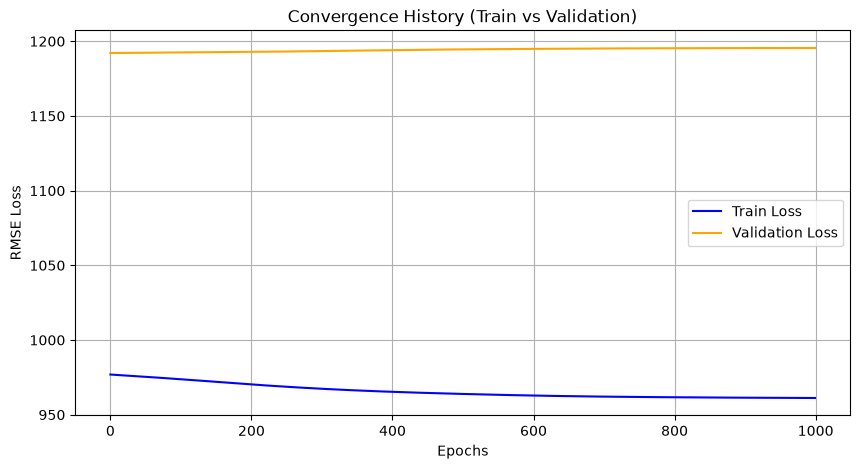

In [ ]:
plt.figure(figsize=(10, 5))

# Plot both Train and Validation Loss on the same axes
plt.plot(history_train_loss, color='blue', label='Train Loss')
plt.plot(history_val_loss, color='orange', label='Validation Loss')

plt.title("Convergence History (Train vs Validation)")
plt.xlabel("Epochs")
plt.ylabel("RMSE Loss")
plt.legend()  # Added legend to distinguish the two lines
plt.grid(True)

plt.show()

# **Data display**

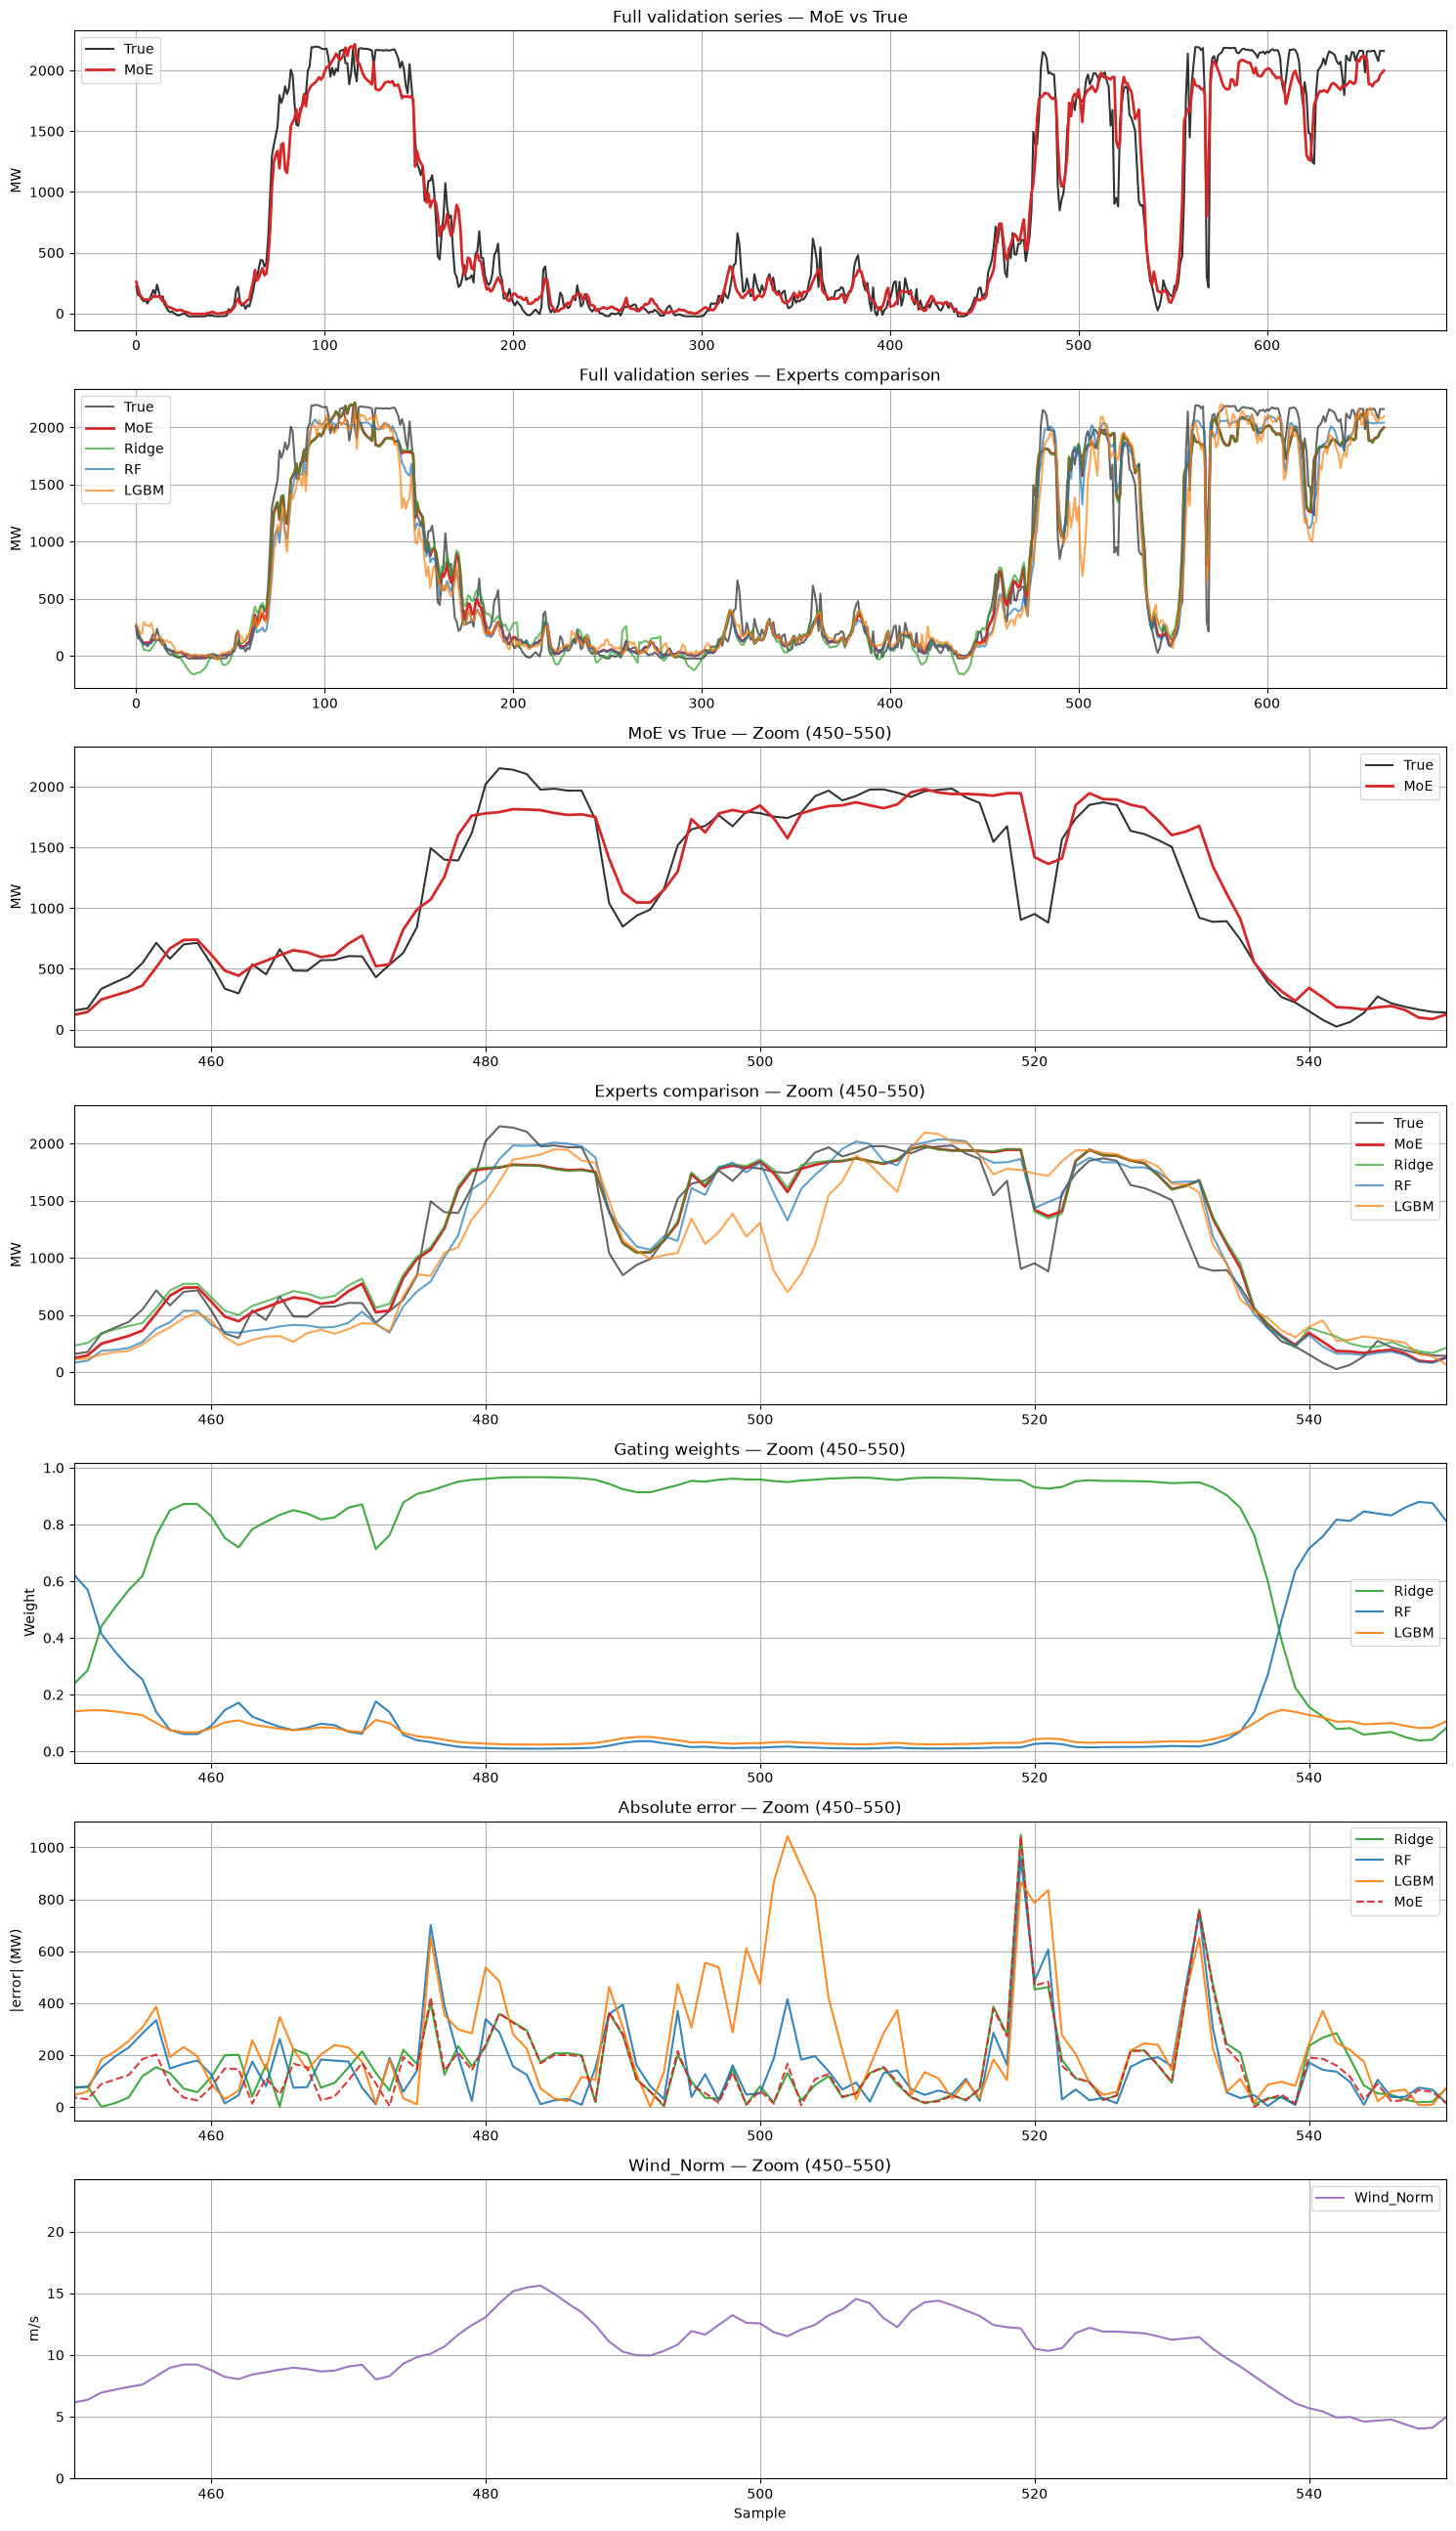

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

model.eval()
with torch.no_grad():
    y_pred_val, w_val = model(X_val_t, E_val_t)


# Predictions
y_true = y_val_t.cpu().numpy().squeeze()
y_pred = y_pred_val.cpu().numpy().squeeze()

# Weights
weights = w_val.cpu().numpy()

# Experts
exp_1 = E_val.to_numpy()[:, 0]   # RIDGE
exp_2 = E_val.to_numpy()[:, 1]   # RF
exp_3 = E_val.to_numpy()[:, 2]   # LGBM

# zoom interval
start, end = 450, 550

# absolute errors
abs_err_moe   = np.abs(y_true - y_pred)
abs_err_ridge = np.abs(y_true - exp_1)
abs_err_rf    = np.abs(y_true - exp_2)
abs_err_lgbm  = np.abs(y_true - exp_3)

# contextual feature
wind_norm = X_val["Wind_Norm"].to_numpy()

# color map
colors = {
    "true": "black",
    "moe": "tab:red",
    "ridge": "tab:green",
    "rf": "tab:blue",
    "lgbm": "tab:orange",
    "wind": "tab:purple"
}

plt.figure(figsize=(15, 26))

# ----------------------------------
# 1 — True vs MoE
# ----------------------------------
plt.subplot(7, 1, 1)
plt.plot(y_true, label="True", color=colors["true"], alpha=0.8)
plt.plot(y_pred, label="MoE", color=colors["moe"], linewidth=2)
plt.legend()
plt.ylabel("MW")
plt.title("Full validation series — MoE vs True")
plt.grid()

# ----------------------------------
# 2 — All models
# ----------------------------------
plt.subplot(7, 1, 2)
plt.plot(y_true, label="True", color=colors["true"], alpha=0.6)
plt.plot(y_pred, label="MoE", color=colors["moe"], linewidth=2)
plt.plot(exp_1, label="Ridge", color=colors["ridge"], alpha=0.7)
plt.plot(exp_2, label="RF", color=colors["rf"], alpha=0.7)
plt.plot(exp_3, label="LGBM", color=colors["lgbm"], alpha=0.7)
plt.legend()
plt.ylabel("MW")
plt.title("Full validation series — Experts comparison")
plt.grid()

# ----------------------------------
# 3 — Zoom MoE
# ----------------------------------
plt.subplot(7, 1, 3)
plt.plot(y_true, label="True", color=colors["true"], alpha=0.8)
plt.plot(y_pred, label="MoE", color=colors["moe"], linewidth=2)
plt.legend()
plt.title(f"MoE vs True — Zoom ({start}–{end})")
plt.xlim((start, end))
plt.ylabel("MW")
plt.grid()

# ----------------------------------
# 4 — Zoom all models
# ----------------------------------
plt.subplot(7, 1, 4)
plt.plot(y_true, label="True", color=colors["true"], alpha=0.6)
plt.plot(y_pred, label="MoE", color=colors["moe"], linewidth=2)
plt.plot(exp_1, label="Ridge", color=colors["ridge"], alpha=0.7)
plt.plot(exp_2, label="RF", color=colors["rf"], alpha=0.7)
plt.plot(exp_3, label="LGBM", color=colors["lgbm"], alpha=0.7)
plt.legend()
plt.title(f"Experts comparison — Zoom ({start}–{end})")
plt.xlim((start, end))
plt.ylabel("MW")
plt.grid()

# ----------------------------------
# 5 — Weights
# ----------------------------------
plt.subplot(7, 1, 5)
plt.plot(weights[:, 0], label="Ridge", color=colors["ridge"], alpha=0.9)
plt.plot(weights[:, 1], label="RF", color=colors["rf"], alpha=0.9)
plt.plot(weights[:, 2], label="LGBM", color=colors["lgbm"], alpha=0.9)
plt.legend()
plt.title(f"Gating weights — Zoom ({start}–{end})")
plt.xlim((start, end))
plt.ylabel("Weight")
plt.grid()

# ----------------------------------
# 6 — Absolute errors
# ----------------------------------
plt.subplot(7, 1, 6)
plt.plot(abs_err_ridge, label="Ridge", color=colors["ridge"], alpha=0.9)
plt.plot(abs_err_rf, label="RF", color=colors["rf"], alpha=0.9)
plt.plot(abs_err_lgbm, label="LGBM", color=colors["lgbm"], alpha=0.9)
plt.plot(abs_err_moe, label="MoE", color=colors["moe"], alpha=0.9, linestyle="dashed")
plt.legend()
plt.title(f"Absolute error — Zoom ({start}–{end})")
plt.xlim((start, end))
plt.ylabel("|error| (MW)")
plt.grid()

# ----------------------------------
# 7 — Wind_Norm
# ----------------------------------
plt.subplot(7, 1, 7)
plt.plot(wind_norm, label="Wind_Norm", color=colors["wind"], alpha=0.9)
plt.legend()
plt.title(f"Wind_Norm — Zoom ({start}–{end})")
plt.xlim((start, end))
plt.xlabel("Sample")
plt.ylabel("m/s")
plt.grid()

plt.tight_layout()
plt.show()